In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def norma_complexa(zc):
  return np.sqrt(np.real(zc*np.conjugate(zc)))

##Determinação de regição de estabilidade para Euler Exponencial

In [ ]:
def phi1(hc):
  if hc == 0:
    f = 1
    return f
  else:
    f = (np.exp(hc) - 1)/(hc)
    return f

def phi2(hc):
  if hc == 0:
    f = 0.5
    return f
  else:
    f = (np.exp(hc) - hc - 1)/(hc)**2
    return f

def phi3(hc):
  if hc == 0:
    f = 1/6
    return f
  else:
    f = (phi2(hc) - 0.5)/(hc)
    return f

def fator_rk3(z,ch = 0):
  f = 1+z+(z**2)*0.5 + (z**3)*(1/6)
  return f

def fator_exp_1(z,ch):
  f = np.exp(ch) + z*phi1(ch)
  return f

def fator_exp_2_1(z,ch): #c_2 = 1
  f = np.exp(ch) + (phi1(ch) - phi2(ch))*z + phi2(ch)*z*(np.exp(ch) + phi1(ch)*z)
  return f

def fator_exp_2_2(z,ch): #c_2 = 1/2
  f = np.exp(ch) + (phi1(ch) - 2*phi2(ch))*z + 2*phi2(ch)*z*(np.exp(ch*0.5) + 0.5*phi1(0.5*ch)*z)
  return f

def fator_exp_3(z,ch): #cox
  a = np.exp(ch*0.5) + 0.5*z*phi1(ch*0.5)
  b = np.exp(ch) -phi1(ch)*z + 2*z*a*phi1(ch)
  f = np.exp(ch) + (4*phi3(ch) - 3*phi2(ch) + phi1(ch))*z + z*a*(-8*phi3(ch) + 4*phi2(ch)) + z*b*(4*phi3(ch) - phi2(ch))
  return f

def fator_etd2(z,ch):
  if ch == 0:
    coef = [1,-(1 + 3*z/2),z/2]
  else:
    coef = [ch**2, - ((ch**2)*np.exp(ch)+z*((1+ch)*np.exp(ch)-1-2*ch)), z*(np.exp(ch)-1-ch)]
  solv = np.roots(coef)
  f = np.max(norma_complexa(solv))
  return f

In [ ]:
def Metodo2(func,hc,tol = 10**(-2)):
  N = 1000
  x = np.linspace(-10,10,N)
  y = np.linspace(-10,10,N)

  X,Y = np.meshgrid(x,y)
  Z = X + 1j*Y

  xcurl = np.array([])
  ycurl = np.array([])



  for i in range(N):
    for j in range(N):
      norma = norma_complexa(func((Z[j][i]), hc))
      if norma > 1 - tol and norma < 1 + tol:
        xcurl = np.append(xcurl,Z[j][i].real)
        ycurl = np.append(ycurl,Z[j][i].imag)

  return xcurl,ycurl

In [ ]:
met = fator_exp_1

x1,y1 = Metodo2(met,  0)
x2,y2 = np.array([]),np.array([])



for i in range(1,6):
  x,y = Metodo2(met,  -i)
  x2,y2 = np.append(x2,x),np.append(y2,y)



<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3691/1508502788.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
/tmp/ipykernel_3691/1508502788.py:20: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)


Text(0, 0.5, 'Im(λ$\\Delta$t)')

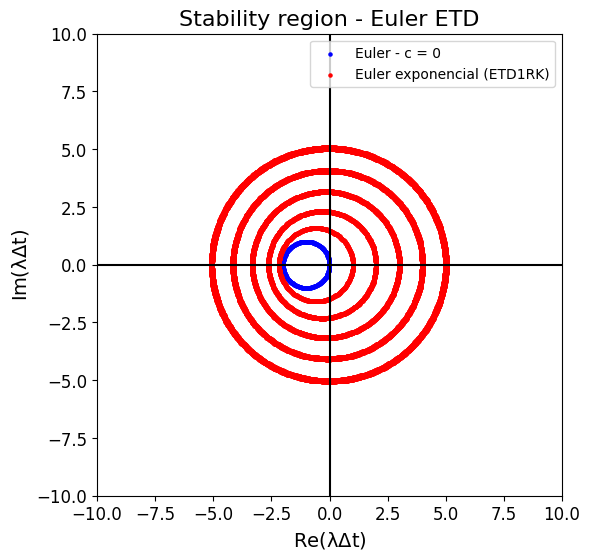

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x1,y1,color = 'b',label = "Euler - c = 0",s = 5)
ax.scatter(x2,y2,color = 'r',label = "Euler exponencial (ETD1RK)",s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')



plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-10,10)
plt.ylim(-10,10)
plt.legend()
plt.title('Stability region - Euler ETD', fontsize = 16)
plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)

##Determinação de regição de estabilidade para ETD2RK1 e 2




In [ ]:
met = fator_exp_2_1

x3,y3 = Metodo2(met,  0)
x4,y4 = np.array([]),np.array([])



for i in range(1,6):
  x,y = Metodo2(met,  -i)
  x4,y4 = np.append(x4,x),np.append(y4,y)

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3691/4155562261.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
/tmp/ipykernel_3691/4155562261.py:20: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)


Text(0, 0.5, 'Im(λ$\\Delta$t)')

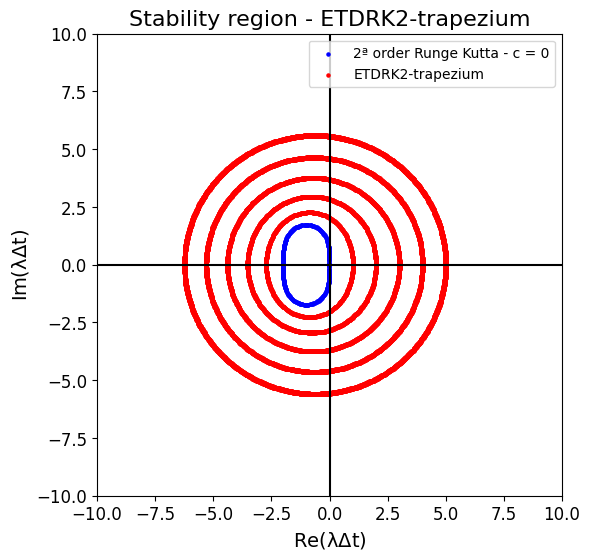

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x3,y3,color = 'b',label = "2ª order Runge Kutta - c = 0",s = 5)
ax.scatter(x4,y4,color = 'r',label = "ETDRK2-trapezium",s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')



plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-10,10)
plt.ylim(-10,10)
plt.legend()
plt.title('Stability region - ETDRK2-trapezium', fontsize = 16)
plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)

In [ ]:
met = fator_exp_2_2

x5,y5 = Metodo2(met,  0)
x6,y6 = np.array([]),np.array([])



for i in range(1,6):
  x,y = Metodo2(met,  -i)
  x6,y6 = np.append(x6,x),np.append(y6,y)

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3691/3290377727.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
/tmp/ipykernel_3691/3290377727.py:20: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)


Text(0, 0.5, 'Im(λ$\\Delta$t)')

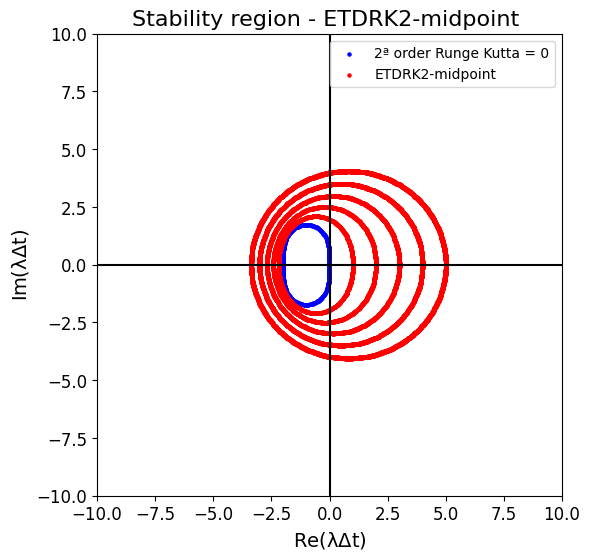

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x5,y5,color = 'b',label = "2ª order Runge Kutta = 0",s = 5)
ax.scatter(x6,y6,color = 'r',label = "ETDRK2-midpoint",s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')



plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-10,10)
plt.ylim(-10,10)
plt.legend()
plt.title('Stability region - ETDRK2-midpoint ', fontsize = 16)
plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)

##Determinação de regição de estabilidade para ETD2




In [ ]:
met = fator_etd2

x7,y7 = Metodo2(met,  0.)
x8,y8 = np.array([]),np.array([])



for i in range(1,6):
  x,y = Metodo2(met,  -i)
  x8,y8 = np.append(x8,x),np.append(y8,y)

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3691/3746342930.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
/tmp/ipykernel_3691/3746342930.py:20: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)


Text(0, 0.5, 'Im(λ$\\Delta$t)')

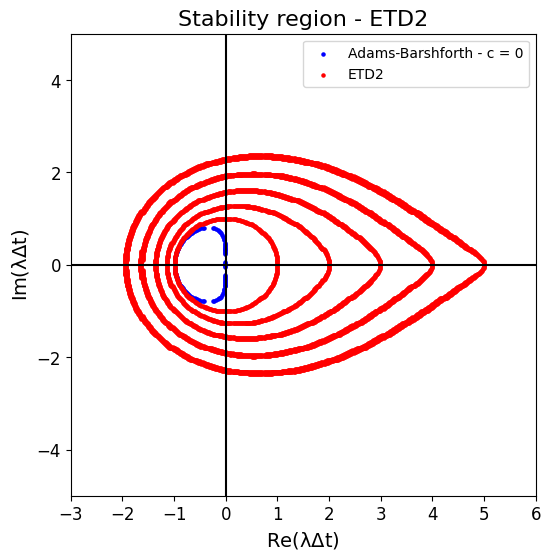

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x7,y7,color = 'b',label = "Adams-Barshforth - c = 0",s = 5)
ax.scatter(x8,y8,color = 'r',label = "ETD2",s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')



plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-3,6)
plt.ylim(-5,5)
plt.legend()
plt.title('Stability region - ETD2', fontsize = 16)
plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)

#ETDRK3

In [ ]:
met = fator_exp_3

x9,y9 = Metodo2(met,  0.001)
x10,y10 = np.array([]),np.array([])




for i in range(1,6):
  x,y = Metodo2(met,  -i)
  x10,y10 = np.append(x10,x),np.append(y10,y)

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3691/1725831582.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
/tmp/ipykernel_3691/1725831582.py:20: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)


Text(0, 0.5, 'Im(λ$\\Delta$t)')

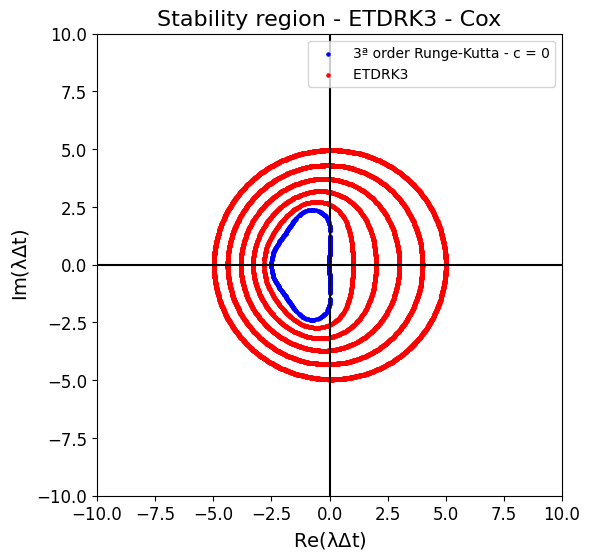

In [ ]:
axxp = (0,0)
axxn = (10,-10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x9,y9,color = 'b',label = "3ª order Runge-Kutta - c = 0",s = 5)
ax.scatter(x10,y10,color = 'r',label = "ETDRK3 ",s = 5)
ax.plot(axxn,axxp,color = 'k')
ax.plot(axxp,axxn,color = 'k')



plt.tick_params(axis='both', which='major', labelsize=12)


plt.xlim(-10,10)
plt.ylim(-10,10)
plt.legend()
plt.title('Stability region - ETDRK3 - Cox', fontsize = 16)
plt.xlabel('Re(λ$\Delta$t)', fontsize = 14)
plt.ylabel('Im(λ$\Delta$t)', fontsize = 14)